<a href="https://colab.research.google.com/github/Mahi200728/CareerPath/blob/main/Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying one of: polynomial modeling, b splines, or GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

A polynomial element can be super helpful especially when trying to analyze non-linear data. So far we have been analyizing very lineraized and simplified data but when we are faced with more complex data there is a huge poossiblity the data we are given is not linear. So by using polynomials we are able to capture curves and other odd shapes which lets us fit our data better. This also allows us to be much more flexible because we can turn a model into any power which can help us model the data better.



---



**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

There are a ton of risks associated with polynomial elements like the huge likelihood of there being a huge amount of overfitting especially as we increase in power. This is a huge issue because it reduces the models ability to generalize which affects the models ability to then model new data. It also makes the model more unpredicatable when given new data which can give you extreme values you don't want. It also makes it harder to explain/interpret the more powers we add to it which essentially makes the model useless.



---



**Task3**:

What's the point of using b splines?

B splines are super useful when modeling non-linear relationships but you don't wanna use a polynomial element. They are also in some ways more useful than polynomials because they help model be more flexible without having to worry about overfitting. This is super useful if the data requires a high degree of polynomial (has a huge issue of overfitting and might oscilate really weirdly (Runge's phenomenon)). It also overall is super effiencnt because the calculations are over a smaller set range compared to the overarching range that comes with polynomials.



---



**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A Gaussian Process is essentially a model that focuses on relationship between the points, their fucntion, rather than just the points (what all the models we've learned about so far does). It essentially is a function that doesn't rely on any prior knowledge (i think don't quote me) rather it learns everything it needs from the data given. This is super useful for a small data set because it is able to better understand and update its learning when given the smaller data set.



---



**Task5**:

Refit a model to the howell data, using one of the following: polynomial model, b splines, or GPs.
Plot the posterior predictive check on a scatter plot

You only need to use one . Remember, the simpler the model is, the better (usually).

Hint: If you use a polynomial or bspline, try a disdributional model


In [1]:
!pip install preliz
!pip install bambi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.1/517.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 9.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 657.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.7 MB/s eta 0:00:00


In [2]:
import preliz as pz
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import bambi as bmb

In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/howell.csv')

In [7]:
#degree 2 polynomial model
model_poly_2 = bmb.Model("weight ~ poly(height, degree=2)", howell)
idata_poly_2 = model_poly_2.fit()

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


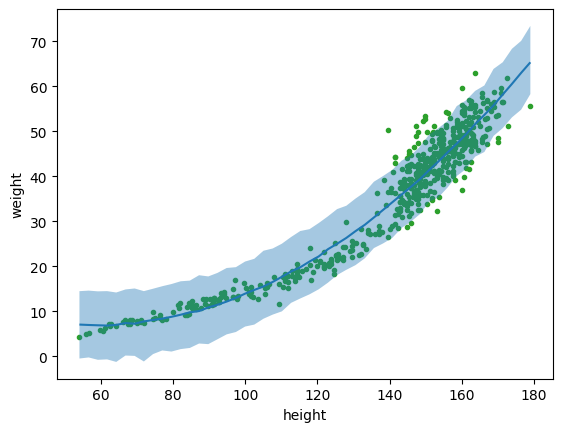

In [8]:
bmb.interpret.plot_predictions(model_poly_2, idata_poly_2, "height", pps=True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

<Axes: xlabel='weight'>

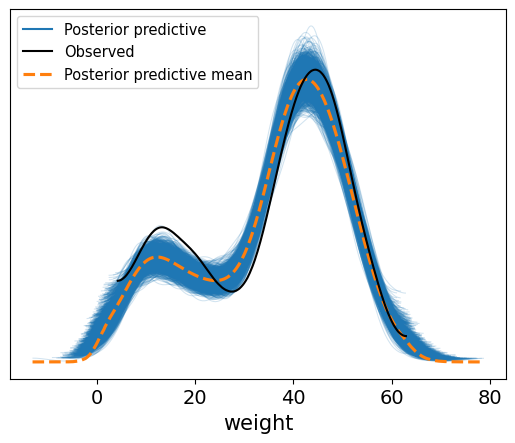

In [9]:
model_poly_2.predict(idata_poly_2, kind="response")
az.plot_ppc(idata_poly_2)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand anything in this article. The main point of this task is to hammer home that good GP implementations are extremely technical.

One think I learned from the article was what a semiparametric GP model is and how it combines parametric componets with non-parametric componets. Within this example the parametric component is the ability to cpature the global trends while the non-parametric components is the un-known patterns/variables which is a huge thing when trying to model as complex as seeing the CO2 traped within ice.



---



**Task7**:

Describe your favorite graph from the article in the previous task. Explain why its your favorite.

The graph for the semiparametric GP model is super cool mainly because it is able to combine CO2 measurements with recent data which helps us gain a fuller understanding of the atmospheric CO2 concentration. The graphs ability to visualize the long term data of the CO2 levels which is able to help us gain a deeper understanding of the data and helps us create better future predictions. It also seems suoer accurate which must have been very hard considering the sheer amount of data given so I think its really cool how specific and accurate they were able to make it. Going based on that I also appreciate how they acknologed the uncertanty that comes along with the model and the data.